<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 3</h3>
    <h3>Ejercicio 4</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistentes: Sebastián Calcagno y Braian Drago<p>
</div>

Aca se analiza tres series mensuales Cemento, Empleo y Empresas.


carga y limpia los datos
revisa faltantes duplicados y valores atipicos
grafica las series y sus FAC/FACP
analiza estacionariedad con ADF KPSS y Z-Andrews
prueba distintas combinaciones de modelos SARIMA
compara modelos mediante AIC, MSE y MAE
analiza los residuos con Ljung-Box, normalidad, FAC y FACP.

vemos el procedimiento completo para seleccionar un modelo SARIMA analizar la serie comprueba su estacionariedad probamos diferentes ordenes y evaluamos el pronostico luego verificamos q los residuos se comporten como ruido blanco

# Importamos y cargamos librerias

In [ ]:
! pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import os
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey, het_breuschpagan
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
from scipy.stats import probplot
from scipy.stats import shapiro, jarque_bera
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acovf, adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error
from arch.unitroot import ZivotAndrews
warnings.filterwarnings('ignore')

# Defino funciones

In [ ]:
# Funcion 1º

def plot_time_series(df,series_names):

    titles = ['Serie Temporal de Cemento', 'Serie Temporal de Empleo', 'Serie Temporal de Empresas']


    fig, axes = plt.subplots(len(series_names), 1, figsize=(15, 10), sharex=True)
    fig.suptitle('Series Temporales Originales')


    for i, series in enumerate(series_names):
        sns.lineplot(ax=axes[i], x='Fecha', y=series, data=df)
        axes[i].set_title(titles[i])


    plt.show()

In [ ]:
# Funcion 2º

def plot_acf_pacf(df_diff, series_names):


    num_series = len(series_names)


    fig, axes = plt.subplots(num_series, 2, figsize=(15, 5 * num_series))
    fig.suptitle('FAC y FACP de las Series Diferenciadas')


    for i, series in enumerate(series_names):
        plot_acf(df_diff[series], ax=axes[i, 0], title=f'FAC de {series}')
        plot_pacf(df_diff[series], ax=axes[i, 1], title=f'FACP de {series}')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# Funcion 3º

def general_plots(residuos, variable_name):

    plt.figure(figsize=(12, 6))
    plt.plot(residuos)
    plt.title(f'Gráfico de Tiempo de los Residuos para {variable_name}')
    plt.xlabel('Tiempo')
    plt.ylabel('Residuos')
    plt.show()



    # Gráfico Q-Q
    plt.figure(figsize=(12, 6))
    probplot(residuos, plot=plt)
    plt.title(f'Gráfico Q-Q de los Residuos para {variable_name}')
    plt.show()

    # Análisis de Autocorrelación
    ## Función de Autocorrelación (ACF)
    plot_acf(residuos, lags=40)
    plt.title(f'Función de Autocorrelación de los Residuos para {variable_name}')
    plt.show()

    ## Función de Autocorrelación Parcial (PACF)
    plot_pacf(residuos, lags=40)
    plt.title(f'Función de Autocorrelación Parcial de los Residuos para {variable_name}')
    plt.show()

In [ ]:
# Funcion 4º

def plot_seasonal_decompose(series, title):
    decomp = seasonal_decompose(series, model='additive', period=12)
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    decomp.observed.plot(ax=axes[0], title=f'Observado - {title}')
    decomp.trend.plot(ax=axes[1], title=f'Tendencia - {title}')
    decomp.seasonal.plot(ax=axes[2], title=f'Estacionalidad - {title}')
    decomp.resid.plot(ax=axes[3], title=f'Residual - {title}')
    axes[3].set_xlabel('Fecha')
    plt.tight_layout()
    plt.show()

In [ ]:
# Funcion 5º


def zivot_andrews_test(series, title='', trend='c', lags=None, trim=0.15, max_lags=None, method='aic'):
    print(f'Zivot-Andrews Test: {title}')
    series = series.astype(float)
    za_test = ZivotAndrews(series, trend=trend, lags=lags, trim=trim, max_lags=max_lags, method=method)
    result = za_test
    print(f'Test Statistic: {result.stat}')
    print(f'P-value: {result.pvalue}')
    print(f'Lags Used: {result.lags}')
    print(f'Critical Values: {result.critical_values}')
    print(f'Number of Observations: {result.nobs}')
    print('\n')

In [ ]:
# Funcion 6º

def adf_test(series, title=''):
    print(f'ADF Test: {title}')
    result = adfuller(series, autolag='AIC')
    labels = ['ADF Test Statistic', 'p-value', '# Lags Used', '# Observations']
    out = pd.Series(result[0:4], index=labels)
    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val
    print(out.to_string())
    print('\n')

In [ ]:
# Funcion 7º

def kpss_test(series, title=''):
    print(f'KPSS Test: {title}')
    result = kpss(series, regression='c', nlags='auto')
    labels = ['KPSS Test Statistic', 'p-value', '# Lags Used']
    out = pd.Series(result[0:3], index=labels)
    for key, val in result[3].items():
        out[f'Critical Value ({key})'] = val
    print(out.to_string())
    print('\n')

In [ ]:
# Funcion 8º

# Función para realizar la prueba HEGY
def hegy_test(series):
    n = len(series)
    t = np.arange(1, n + 1)
    pi = np.pi
    freqs = [pi, pi/6, -pi/6]
    for freq in freqs:
        series[f'cos{freq}'] = np.cos(freq * t)
        series[f'sin{freq}'] = np.sin(freq * t)
    series['trend'] = t
    series['constant'] = 1
    X = series.drop(columns=[series.columns[0]])
    y = series[series.columns[0]]
    model = sm.OLS(y, X).fit()
    return model.summary()

In [ ]:
# Funcion 9º

def find_best_sarima_model(df, column, pdq, seasonal_pdq):
    best_aic = float('inf')
    best_order = None
    best_seasonal_order = None
    best_model = None
    results_dict = {}

    for param in pdq:
        for param_seasonal in seasonal_pdq:
            try:
                model_results = fit_sarima_model(df[column].dropna(), param, param_seasonal)
                if model_results.aic < best_aic:
                    results_dict['best_aic'] = model_results.aic
                    results_dict['best_order'] = param
                    results_dict['best_seasonal_order'] = param_seasonal
                    results_dict['best_model'] = model_results
            except:
                continue


    print(f"Mejor modelo SARIMA para {column}: {results_dict['best_order']}x{results_dict['best_seasonal_order']} - AIC: {results_dict['best_aic']}\n")
    print(results_dict['best_model'].summary())
    return results_dict

In [ ]:
# Funcion 10º

def fit_sarima_model(df, order, seasonal_order):
    model = SARIMAX(df, order=order, seasonal_order=seasonal_order)
    results = model.fit(disp=False)
    return results

In [ ]:
# Funcion 11º

def evaluate_sarima_model(df, column, order, seasonal_order, train_ratio=0.8, diff=True):
    if diff:
        df_diff = df.diff().dropna().reset_index(drop=True)

    train_size = int(len(df[column]) * train_ratio)
    train, test = df[column][0:train_size], df[column][train_size:]
    model = fit_sarima_model(train, order, seasonal_order)

    # Make predictions on the test set
    predictions = model.get_forecast(steps=len(test)).predicted_mean

    # Calculate MSE and MAE
    mse = mean_squared_error(test, predictions)
    mae = mean_absolute_error(test, predictions)
    print(f'Metricas para {column}')
    print(f'Error Cuadrático Medio (MSE): {mse}')
    print(f'Error Absoluto Medio (MAE): {mae}')

    return mse, mae

In [ ]:
# Funcion 12º

def residual_tests(results_cemento, results_empleo, results_empresas):
    # Create an empty DataFrame to store results
    stats_results = pd.DataFrame(columns=['Ljung-Box Stat', 'Ljung-Box p-value',
                                          'Jarque-Bera Stat', 'Jarque-Bera p-value',
                                          'Shapiro-Wilk Stat',
                                          'Shapiro-Wilk p-value', 'ADF Stat',
                                          'ADF p-value', 'ADF Used Lag', 'ADF Number of Observations'])

    # List of results to iterate over
    results_list = [results_cemento, results_empleo, results_empresas]

    for name, result in zip(series_names, results_list):
        # Extract residuals
        residuos = result['best_model'].resid

        # Perform the Ljung-Box test
        lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
        lb_stat = lb_test['lb_stat'].iloc[0]
        lb_pvalue = lb_test['lb_pvalue'].iloc[0]

        # Perform the Jarque-Bera test
        jb_test = jarque_bera(residuos)
        jb_stat = jb_test[0]
        jb_pvalue = jb_test[1]



        # Perform the Shapiro-Wilk test
        sw_test = shapiro(residuos)
        sw_stat = sw_test[0]
        sw_pvalue = sw_test[1]

        # Perform the Augmented Dickey-Fuller (ADF) test
        adf_test = adfuller(residuos)
        adf_stat = adf_test[0]
        adf_pvalue = adf_test[1]
        adf_usedlag = adf_test[2]
        adf_nobs = adf_test[3]

        # Store results in the DataFrame
        stats_results.loc[name] = [lb_stat, lb_pvalue, jb_stat, jb_pvalue,
                                   sw_stat, sw_pvalue, adf_stat,
                                   adf_pvalue, adf_usedlag, adf_nobs]

    return stats_results

In [ ]:
# Funcion 13º

def get_prediction_with_confidence(df, var, n_forecast, best_model):
    last_observed_value = df[var].iloc[-1]
    df_diff = df.diff().dropna().reset_index(drop=True)
    forecast_results = best_model.get_forecast(steps=n_forecast, alpha=0.05).summary_frame()
    # Graficar las predicciones junto con los intervalos de confianza
    plt.figure(figsize=(12, 6))
    plt.plot(df_diff[var].dropna().index, df_diff[var].dropna(), label='Datos observados')
    plt.plot(forecast_results.index, forecast_results['mean'], label='Pronóstico', color='r')
    plt.fill_between(forecast_results.index, forecast_results['mean_ci_lower'], forecast_results['mean_ci_upper'], color='r', alpha=0.3)
    plt.title(f'Pronóstico de {n_forecast} meses para la serie diferenciada {var} con Intervalos de Confianza al 95%')
    plt.xlabel('Tiempo')
    plt.ylabel(var)
    plt.legend()
    plt.show()

In [ ]:
# Funcion 14º

def get_prediction_original(df, var, n_forecast,best_model):
    last_observed_value = df[var].iloc[-1]
    forecast_results = best_model.get_forecast(steps=n_forecast, alpha=0.05).summary_frame()
    # Inicializar una lista para almacenar los pronósticos en el nivel original
    forecast_original = [last_observed_value]

    # Antidiferenciar los pronósticos
    for i in range(n_forecast):
        next_value = forecast_original[-1] + forecast_results['mean'].iloc[i]
        forecast_original.append(next_value)

    # Convertir la lista a un DataFrame de pandas para facilitar el manejo
    forecast_original = pd.DataFrame(forecast_original[1:], columns=['Forecast'], index=forecast_results.index)

    # Graficar las predicciones en el nivel original
    plt.figure(figsize=(12, 6))
    plt.plot(df[var].index, df[var], label='Datos observados')
    plt.plot(forecast_original.index, forecast_original['Forecast'], label='Pronóstico', color='r')
    plt.title(f'Pronóstico de {n_forecast} meses para la serie orignal sin intervalos de confianza{var}')
    plt.xlabel('Tiempo')
    plt.ylabel(var)
    plt.legend()
    plt.show()

In [ ]:
# Funcion 15º

def get_original_prediction_with_confidence(df, var, n_forecast, best_model):
    last_observed_value = df[var].iloc[-1]
    df_diff = df.diff().dropna().reset_index(drop=True)
    forecast_results = best_model.get_forecast(steps=n_forecast, alpha=0.05).summary_frame()
    # Inicializar listas para almacenar los pronósticos y los intervalos de confianza en el nivel original
    forecast_original = [last_observed_value]
    lower_bound = [last_observed_value]
    upper_bound = [last_observed_value]

    # Antidiferenciar los pronósticos y los intervalos de confianza
    for i in range(n_forecast):
        next_value = forecast_original[-1] + forecast_results['mean'].iloc[i]
        next_lower = lower_bound[-1] + forecast_results['mean_ci_lower'].iloc[i]
        next_upper = upper_bound[-1] + forecast_results['mean_ci_upper'].iloc[i]

        forecast_original.append(next_value)
        lower_bound.append(next_lower)
        upper_bound.append(next_upper)

    # Convertir las listas a DataFrames de pandas para facilitar el manejo
    forecast_df = pd.DataFrame({
        'Forecast': forecast_original[1:],
        'Lower_Bound': lower_bound[1:],
        'Upper_Bound': upper_bound[1:]
    }, index=forecast_results.index)

    # Graficar las predicciones en el nivel original junto con los intervalos de confianza
    plt.figure(figsize=(12, 6))
    plt.plot(df[var].index, df[var], label='Datos observados')
    plt.plot(forecast_df.index, forecast_df['Forecast'], label='Pronóstico', color='r')
    plt.fill_between(forecast_df.index, forecast_df['Lower_Bound'], forecast_df['Upper_Bound'], color='r', alpha=0.3)
    plt.title(f'Pronóstico de {n_forecast} meses para la serie original {var} con Intervalos de Confianza al 95%')
    plt.xlabel('Tiempo')
    plt.ylabel(var)
    plt.legend()
    plt.show()

In [ ]:
# Funcion 16º

def train_SARIMA_and_plot(df, n_forecast, variable):
    df_diff = df.diff().dropna().reset_index(drop=True)
    model = SARIMAX(df_diff[variable].dropna(),
                order=results_cemento['best_order'],
                seasonal_order=results_cemento['best_seasonal_order'])

    best_model = model.fit(disp=False)
    get_prediction_with_confidence(df,variable,n_forecast, best_model)
    get_prediction_original(df,variable, n_forecast, best_model)
    get_original_prediction_with_confidence(df,variable, n_forecast, best_model)

In [ ]:
# Funcion 17º

def fixtype(df_c):
    df = df_c.copy()
    # Verificar el tipo de datos del índice
    index_type = df.index.dtype
    print(f"El tipo de datos del índice es: {index_type}")

    # Verificar si el índice es de tipo DateTime
    if pd.api.types.is_datetime64_any_dtype(index_type):
        print("El índice es de tipo DateTime.")
    else:
        print("El índice NO es de tipo DateTime. Convirtiendo...")
        if 'Fecha' in df.columns:
            df['Fecha'] = pd.to_datetime(df['Fecha'])
            print("Índice convertido a DateTime.")
            return df.set_index('Fecha')
        else:
            print("No se encontró la columna 'Fecha' para convertir.")

In [ ]:
# Funcion 18º

def evaluate_sarima_model_with_boxcox(df, column, order, seasonal_order, lambda_boxcox, train_ratio=0.8, diff=True):
    # Apply Box-Cox transformation if necessary
    if lambda_boxcox is not None:
        df[column], _ = boxcox(df[column])

    if diff:
        df_diff = df.diff().dropna().reset_index(drop=True)

    train_size = int(len(df[column]) * train_ratio)
    train, test = df[column][0:train_size], df[column][train_size:]

    model = fit_sarima_model(train, order, seasonal_order)

    # Make predictions on the test set
    predictions = model.get_forecast(steps=len(test)).predicted_mean

    # Invert Box-Cox transformation on predictions
    if lambda_boxcox is not None:
        predictions = inv_boxcox(predictions, lambda_boxcox)
        test = inv_boxcox(test, lambda_boxcox)

    # Calculate MSE and MAE
    mse = mean_squared_error(test, predictions)
    mae = mean_absolute_error(test, predictions)
    print(f'Metricas para {column}')
    print(f'Error Cuadrático Medio (MSE): {mse}')
    print(f'Error Absoluto Medio (MAE): {mae}')

    return mse, mae

# Cargar bases y trabajarlas

In [ ]:
url='https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/refs/heads/main/AST_TP1.csv'
df = pd.read_csv(url,sep=';')

In [ ]:
meses = {
    "ene": "Jan", "feb": "Feb", "mar": "Mar", "abr": "Apr",
    "may": "May", "jun": "Jun", "jul": "Jul", "ago": "Aug",
    "sep": "Sep", "oct": "Oct", "nov": "Nov", "dic": "Dec"
}


df["Fecha"] = df["Fecha"].replace(meses, regex=True)

df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors="coerce")


In [ ]:
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%b-%y")

In [ ]:
print(df.tail())

         Fecha  Cemento  Empleo  Empresas
178 2022-04-01    29589   67592      4400
179 2022-05-01    30545   68190      3773
180 2022-06-01    31198   68402      3865
181 2022-07-01    30301   68796      3950
182 2022-08-01    33207   71255      4029


In [ ]:
df.set_index('Fecha', inplace=True)

In [ ]:
print(df.tail())

            Cemento  Empleo  Empresas
Fecha                                
2022-04-01    29589   67592      4400
2022-05-01    30545   68190      3773
2022-06-01    31198   68402      3865
2022-07-01    30301   68796      3950
2022-08-01    33207   71255      4029


In [ ]:
print(df.index.dtype)


datetime64[ns]


In [ ]:
# Analisis de datos faltantes
missing_data = df.isnull().sum().reset_index().rename(columns={0: 'Missing_Count', 'index': 'Column_Name'})
missing_data['Missing_Percentage'] = (missing_data['Missing_Count'] / len(df)) * 100

In [ ]:
# Analisis de datos duplicados
duplicate_data = df.duplicated().sum()

In [ ]:
# Analisis de valores atipicos utilizando el metodo del rango intercuartil
outliers_data = {}
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers_count = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    outliers_data[col] = outliers_count

# Metodo Z-Score --> Z-score mide cuántas desviaciones estandar esta un valor por encima o por debajo de la media
z_scores = stats.zscore(df.select_dtypes(include=['int64', 'float64']))
abs_z_scores = np.abs(z_scores)
outliers_z_score = (abs_z_scores > 3).sum(axis=0)

# Método de Tukey ---> Detecta valores muy atipicos "3 X IQR "
outliers_tukey = {}
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers_count = ((df[col] < (Q1 - 3 * IQR)) | (df[col] > (Q3 + 3 * IQR))).sum()
    outliers_tukey[col] = outliers_count

In [ ]:
outliers_z_score, outliers_tukey, missing_data, duplicate_data, outliers_data

(array([2, 2, 0]),
 {'Cemento': np.int64(0), 'Empleo': np.int64(1), 'Empresas': np.int64(0)},
   Column_Name  Missing_Count  Missing_Percentage
 0     Cemento              0                 0.0
 1      Empleo              0                 0.0
 2    Empresas              0                 0.0,
 np.int64(0),
 {'Cemento': np.int64(11), 'Empleo': np.int64(12), 'Empresas': np.int64(0)})

In [ ]:
series_names = ['Cemento', 'Empleo', 'Empresas']

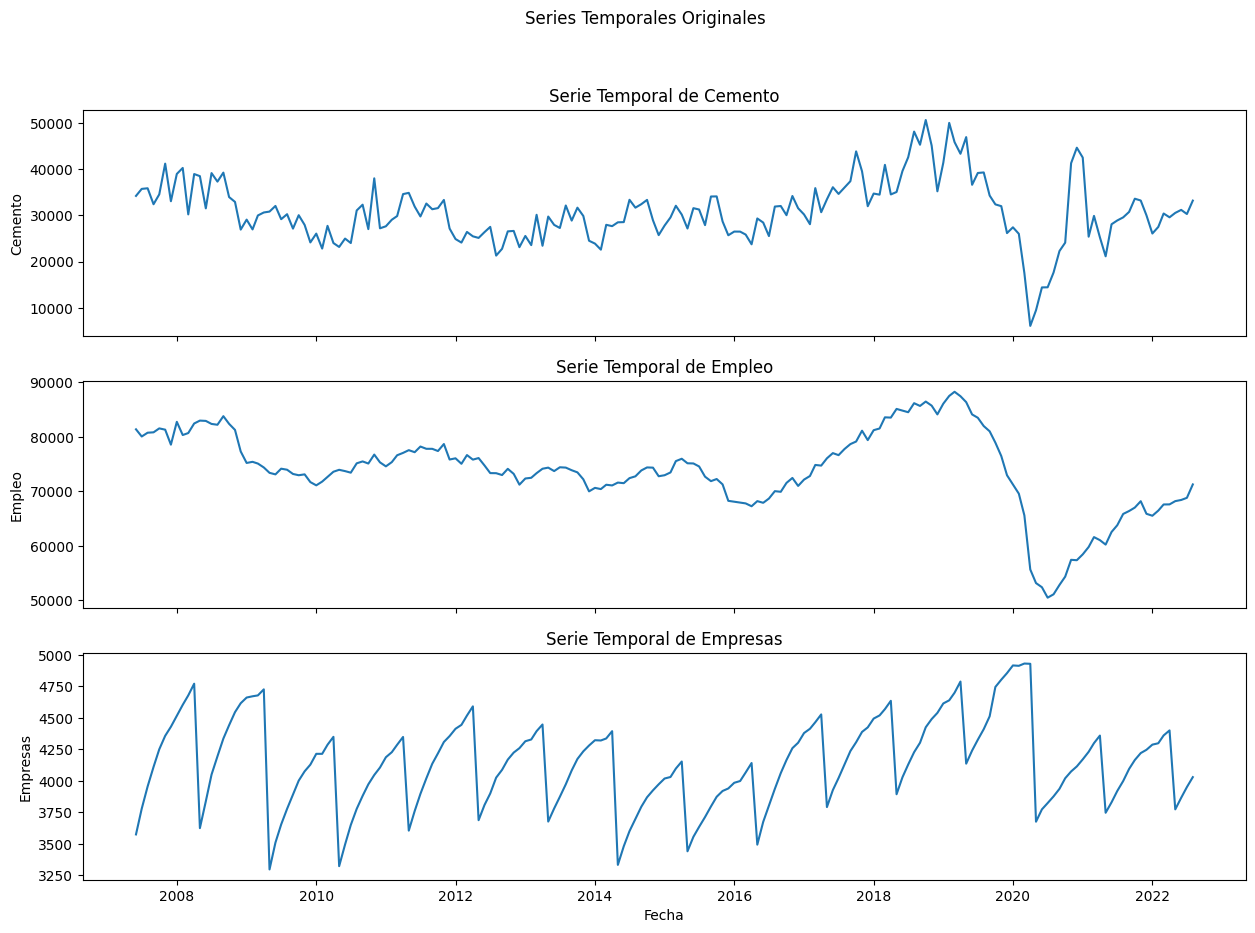

In [ ]:
plot_time_series(df,series_names)

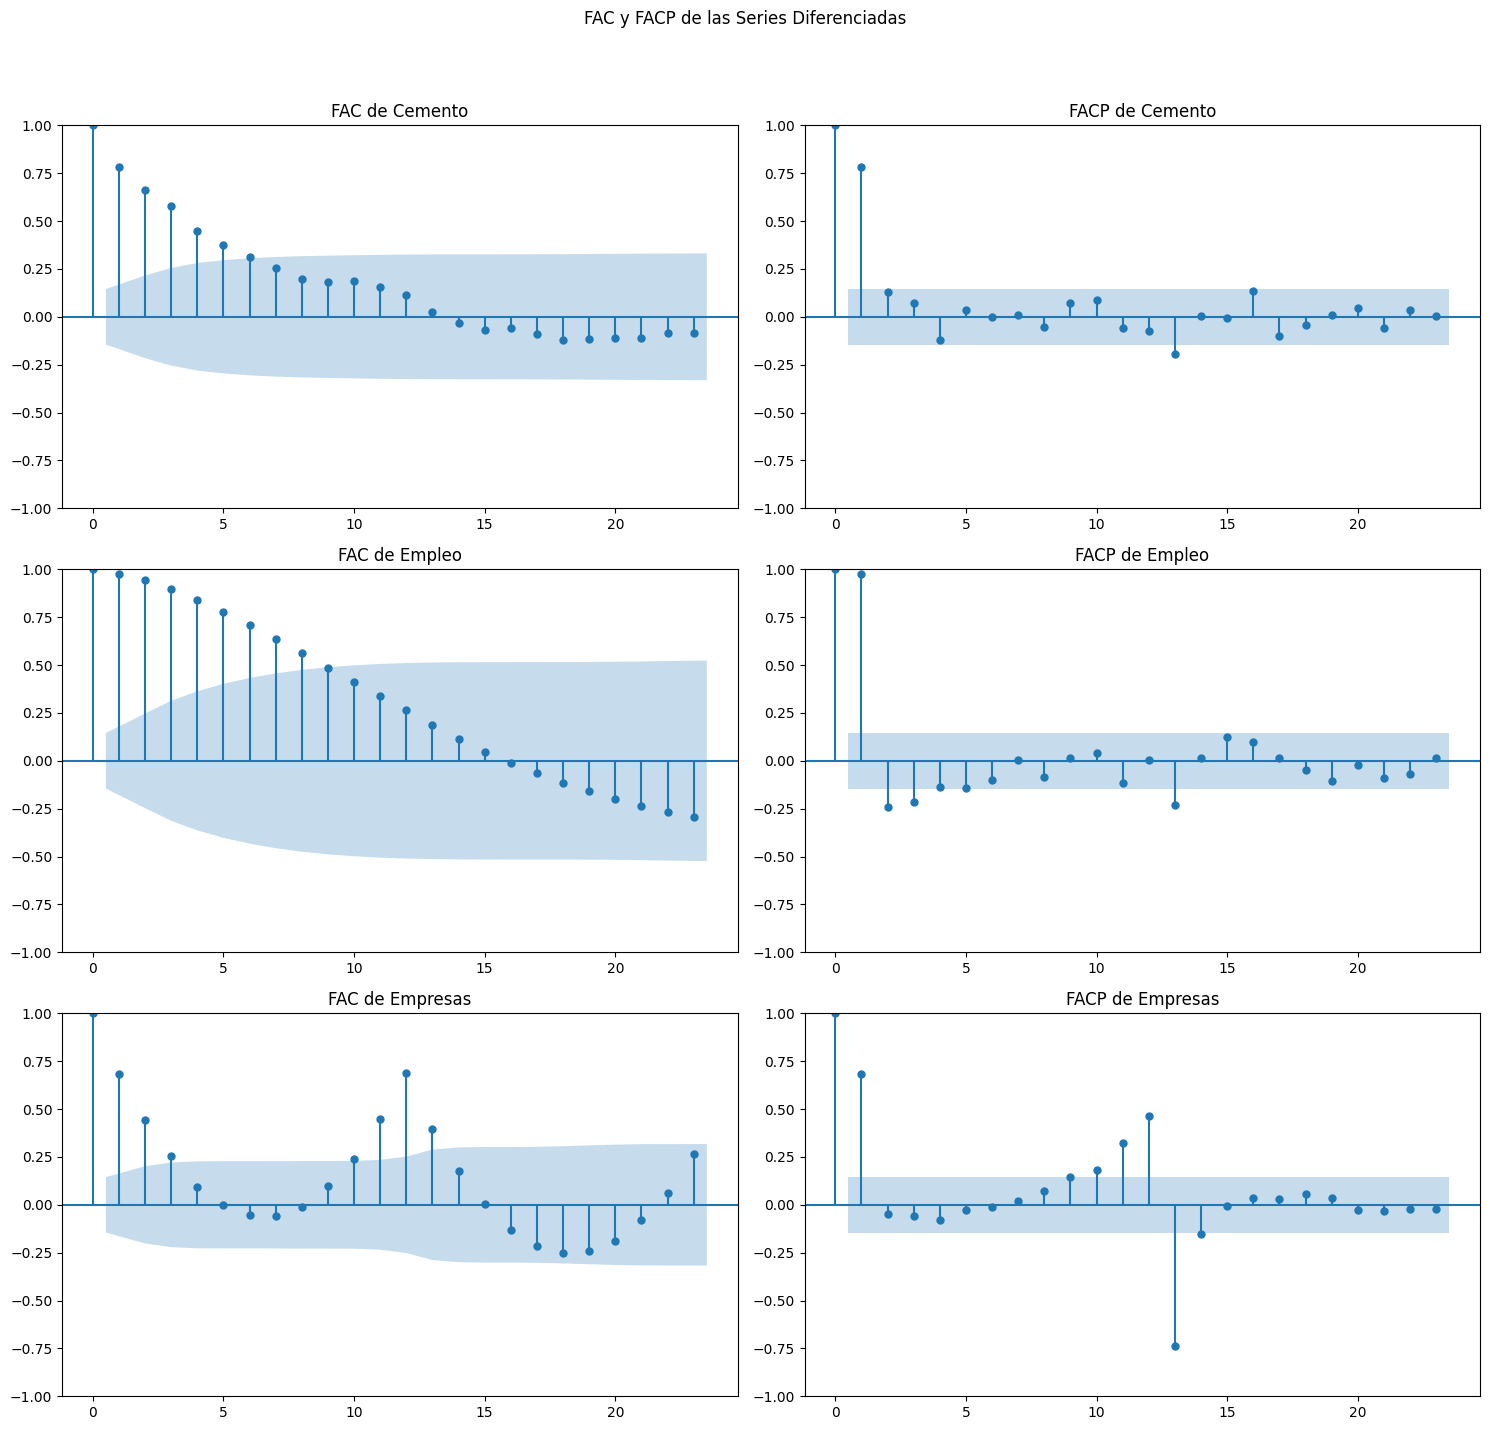

In [ ]:
plot_acf_pacf(df, series_names)

Zivot-Andrews Test--->

H₀= La serie tiene raiz unitaria con posible quiebre estructural.
H₁= La serie es estacionaria alrededor de una media o tendencia con quiebre estructural.


0.00928 menor que 0.01 y el estadistico -5.2955 es menor que el valor crítico al 1% (-5.27644).

Esto significa que rechazamos la ho de raiz unitaria incluso al nivel más estricto de significancia (1%).

ADF Tes

Hipótesis:

H₀ --> raiz unitaria -->la serie no es estacionaria. <br>
H₁ -->no hay raiz unitaria --> la serie es estacionaria.

Datos del ejemplo
Estadístico ADF (-4.6947) menor q todos los valores criticos incluso al 1% rechazamos H₀.

El p-value confirma ya q es muy bajo indicando estacionariedad con alta confianza.

Entonces la serie es estacionaria.

KPSS test

Hip nula = La serie es estacionaria.
Hip alternativa = La serie tiene raiz unitaria (no estacionaria).

La estadistica del test 0.1325 es menor que todos los valores criticos. Asi indica evidencia insuficiente para rechazar la hipótesis nula.

El p-valor es 0.1 que es mayor a los niveles usuales de significancia (0.01, 0.05, 0.1). Esto tb muestra que no rechazamos la hip nula.

In [ ]:
# Pruebas de raices unitarias en las series diferenciadas
for serie in series_names:
    zivot_andrews_test(df[serie], title=serie)
    adf_test(df[serie], serie)
    kpss_test(df[serie], serie)

Zivot-Andrews Test: Cemento
Test Statistic: -5.29550124039099
P-value: 0.009280707909773991
Lags Used: 0
Critical Values: {'1%': np.float64(-5.27644), '5%': np.float64(-4.81067), '10%': np.float64(-4.56618)}
Number of Observations: 183


ADF Test: Cemento
ADF Test Statistic       -4.694716
p-value                   0.000086
# Lags Used               0.000000
# Observations          182.000000
Critical Value (1%)      -3.466800
Critical Value (5%)      -2.877555
Critical Value (10%)     -2.575308


KPSS Test: Cemento
KPSS Test Statistic      0.132505
p-value                  0.100000
# Lags Used              8.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000


Zivot-Andrews Test: Empleo
Test Statistic: -5.351919904059489
P-value: 0.007296365761073841
Lags Used: 12
Critical Values: {'1%': np.float64(-5.27644), '5%': np.float64(-4.81067), '10%': np.float64(-4.56618)}
Number of Observations: 183



In [ ]:
# Definir rangos para los parámetros p, d, q, P, D, Q y S
p = d = q = range(0, 2)
P = D = Q = range(0, 2)
S = [12]  # Frecuencia estacional

# Generar todas las combinaciones diferentes de p, d, q, P, D, Q y S
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], S[0]) for x in list(itertools.product(P, D, Q))]

In [ ]:
results_cemento = find_best_sarima_model(df, 'Cemento', pdq, seasonal_pdq)

Mejor modelo SARIMA para Cemento: (1, 1, 1)x(1, 1, 1, 12) - AIC: 3349.2957447270473

                                     SARIMAX Results                                      
Dep. Variable:                            Cemento   No. Observations:                  183
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1669.648
Date:                            Thu, 14 Aug 2025   AIC                           3349.296
Time:                                    15:14:57   BIC                           3364.975
Sample:                                06-01-2007   HQIC                          3355.658
                                     - 08-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9509      0.

In [ ]:
mse, mae = evaluate_sarima_model(df,
                                 'Cemento',
                                 results_cemento['best_order'],
                                 results_cemento['best_seasonal_order'])

Metricas para Cemento
Error Cuadrático Medio (MSE): 313073301.1779692
Error Absoluto Medio (MAE): 16112.214335026978


In [ ]:
results_empleo = find_best_sarima_model(df, 'Empleo', pdq, seasonal_pdq)

Mejor modelo SARIMA para Empleo: (1, 1, 1)x(1, 1, 1, 12) - AIC: 3035.5803468294785

                                     SARIMAX Results                                      
Dep. Variable:                             Empleo   No. Observations:                  183
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1512.790
Date:                            Thu, 14 Aug 2025   AIC                           3035.580
Time:                                    15:27:00   BIC                           3051.259
Sample:                                06-01-2007   HQIC                          3041.943
                                     - 08-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8152      0.0

In [ ]:
mse, mae = evaluate_sarima_model(df,
                                 'Empleo',
                                 results_empleo['best_order'],
                                 results_empleo['best_seasonal_order'])

Metricas para Empleo
Error Cuadrático Medio (MSE): 463778099.73071915
Error Absoluto Medio (MAE): 19977.579697860107


In [ ]:
results_empresas = find_best_sarima_model(df, 'Empresas', pdq, seasonal_pdq)

Mejor modelo SARIMA para Empresas: (1, 1, 1)x(1, 1, 1, 12) - AIC: 1981.024033500618

                                     SARIMAX Results                                      
Dep. Variable:                           Empresas   No. Observations:                  183
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -985.512
Date:                            Thu, 14 Aug 2025   AIC                           1981.024
Time:                                    15:27:29   BIC                           1996.703
Sample:                                06-01-2007   HQIC                          1987.386
                                     - 08-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9996      0.

In [ ]:
mse, mae = evaluate_sarima_model(df,
                                 'Empresas',
                                 results_empresas['best_order'],
                                 results_empresas['best_seasonal_order'], diff=True)

Metricas para Empresas
Error Cuadrático Medio (MSE): 477482.6082206421
Error Absoluto Medio (MAE): 614.4244433761469


In [ ]:
residual_tests(results_cemento, results_empleo, results_empresas)

,Ljung-Box Stat,Ljung-Box p-value,Jarque-Bera Stat,Jarque-Bera p-value,Shapiro-Wilk Stat,Shapiro-Wilk p-value,ADF Stat,ADF p-value,ADF Used Lag,ADF Number of Observations
Cemento,17.749637,0.059337,788.133417,7.227748e-172,0.885140,1.218749e-10,-18.029742,2.678702e-30,0.0,182.0
Empleo,2.317958,0.993271,57587.520243,0.000000e+00,0.267363,1.945730e-26,-3.842074,2.505014e-03,14.0,168.0
Empresas,4.792879,0.904577,70432.514235,0.000000e+00,0.261604,1.606658e-26,-8.902079,1.164047e-14,1.0,181.0


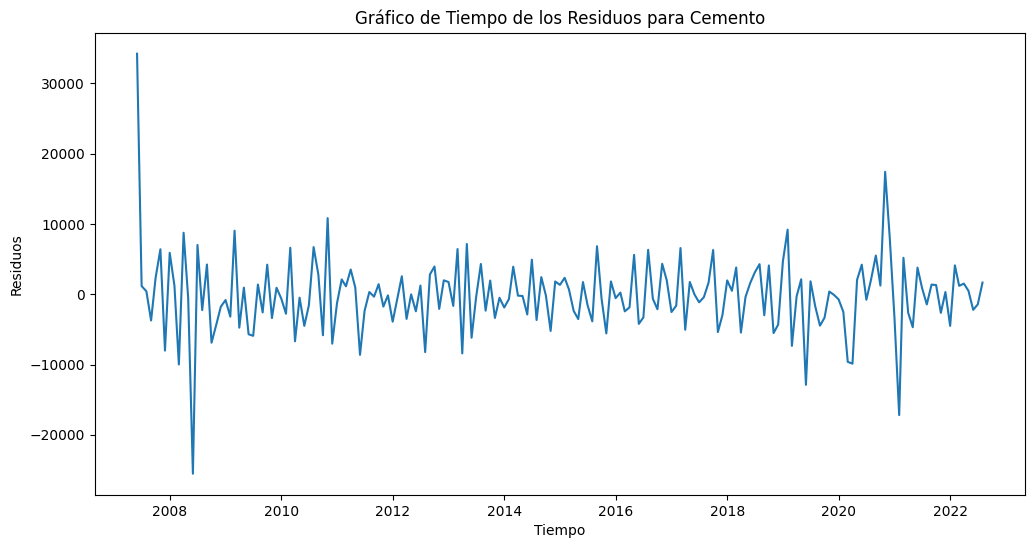

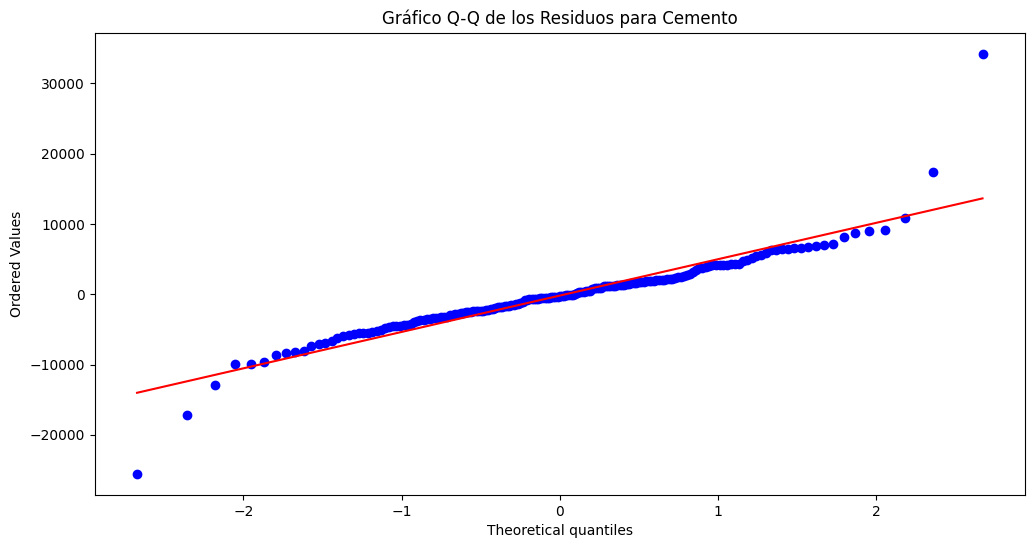

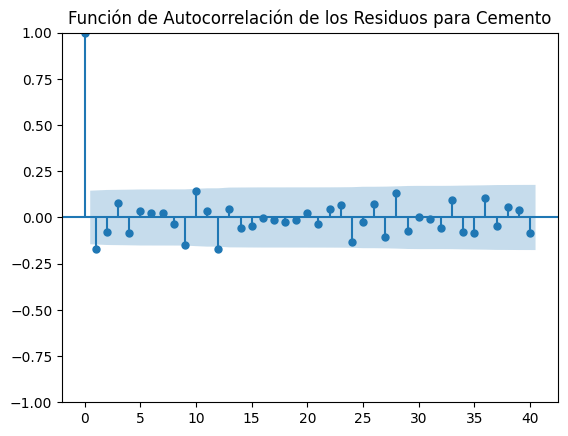

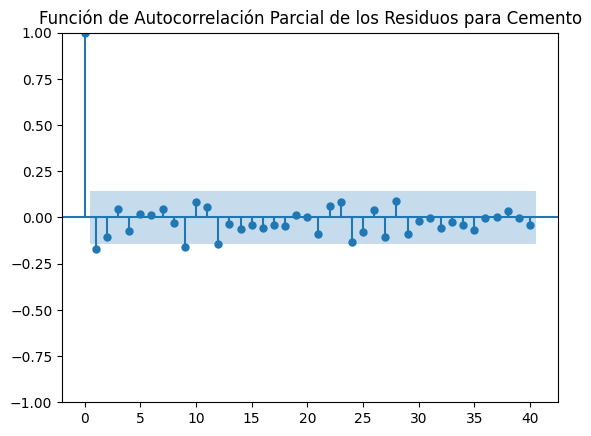

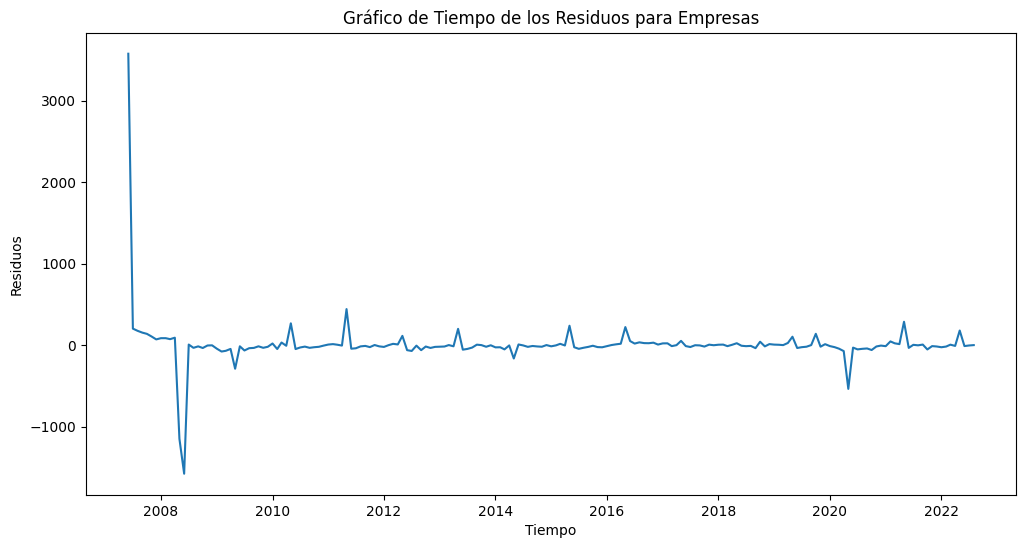

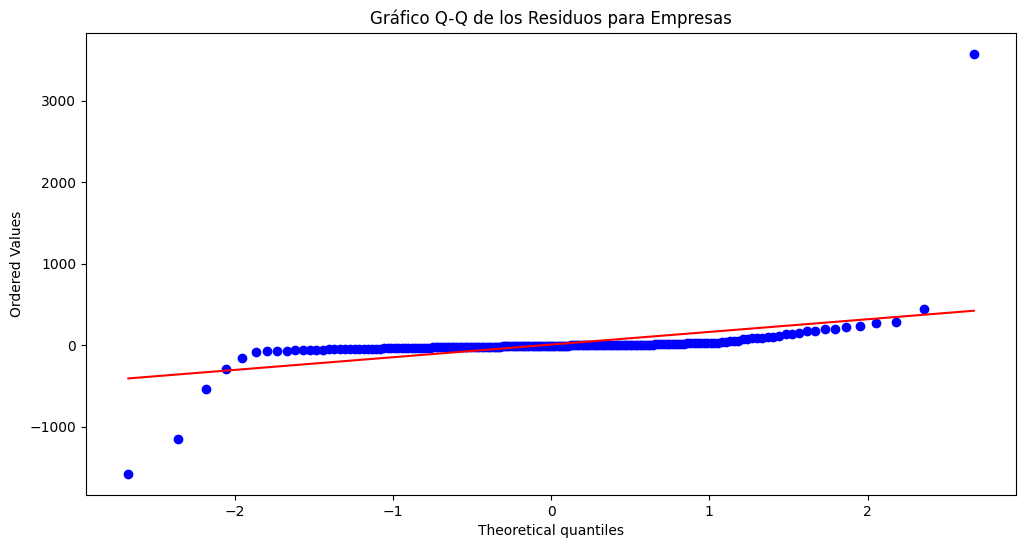

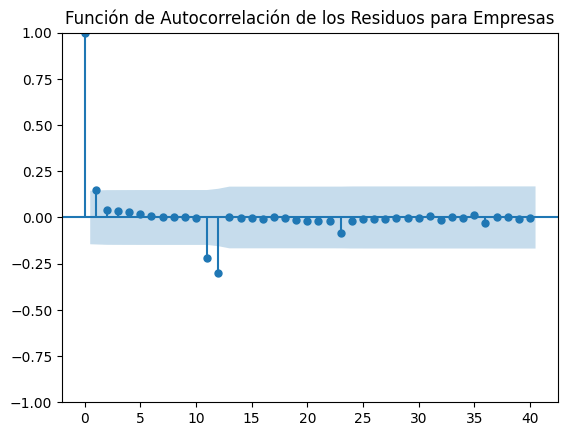

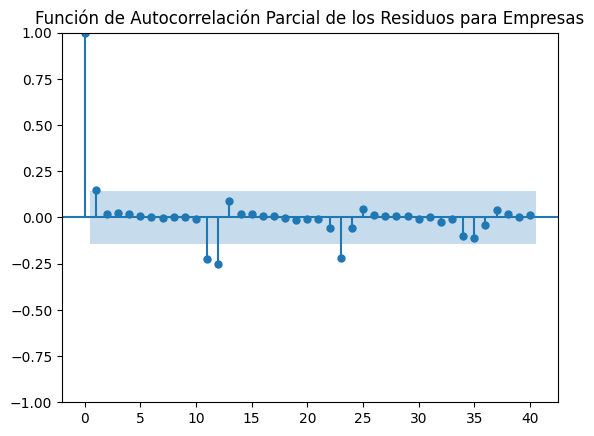

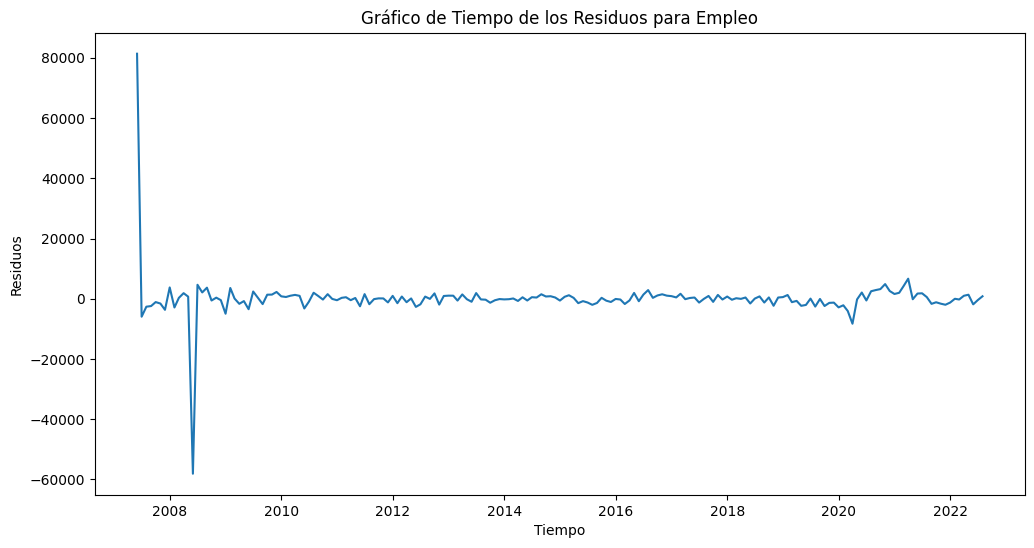

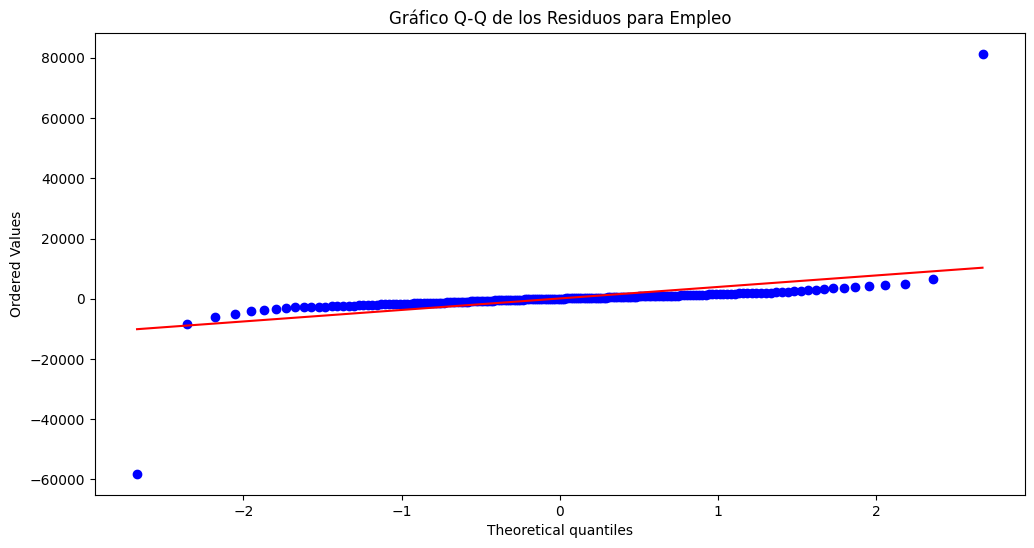

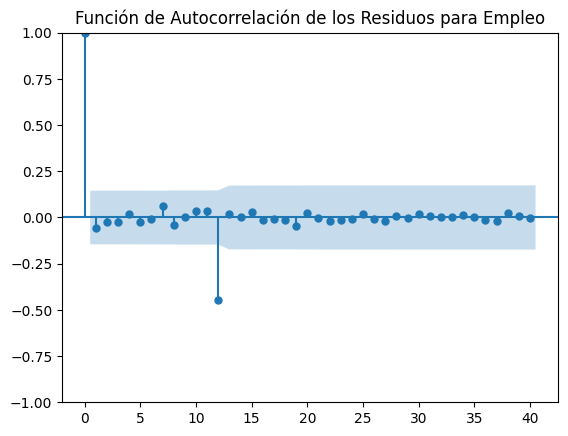

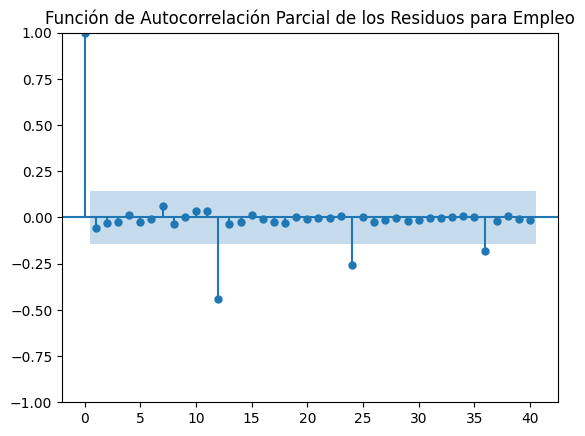

In [ ]:
general_plots(results_cemento['best_model'].resid, 'Cemento')
general_plots(results_empresas['best_model'].resid, 'Empresas')
general_plots(results_empleo['best_model'].resid, 'Empleo')